In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
from time import time
from torchvision import datasets, transforms
from torch import nn, optim

In [4]:
transform = transforms.ToTensor() # Definindo a conversão de imagem para tensor

trainset = datasets.MNIST('~/.pytorch/MNIST_data/', download=True, train=True, transform=transform) # Carrega a parte de treino do dataset
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True) # Cria um buffer para pegar os dados por partes

valset = datasets.MNIST('~/.pytorch/MNIST_data/', download=True, train=False, transform=transform) # Carrega a parte de validação do dataset
valloader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=True) # Cria um buffer para pegar os dados por partes

100%|██████████| 9.91M/9.91M [00:00<00:00, 56.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.63MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.48MB/s]


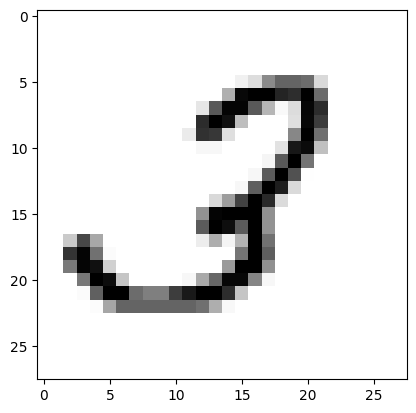

In [7]:
dataiter = iter(trainloader)
imagens, etiquetas = next(dataiter)
plt.imshow(imagens[0].numpy().squeeze(), cmap='gray_r')

In [8]:
print(imagens[0].shape) # Para verificar as dimensões do tensor de cada imagem
print(etiquetas[0].shape) # Para verificar as dimensões do tensor de cada etiqueta

torch.Size([1, 28, 28])
torch.Size([])


In [9]:
class Modelo(nn.Module):
  def __init__(self):
    super(Modelo, self).__init__()
    self.linear1 = nn.Linear(28*28, 128) # Camada de entrada de 784 neuronios que se ligam a 128
    self.linear2 = nn.Linear(128, 64) # Camada interna 1, entrada de 128 neuronios que se ligam a 64
    self.linear3 = nn.Linear(64, 10) # Camada interna 2, entrada de 64 neuronios que se ligam a 10
    # Para a camada de saida nao e necessario definir nada pois so precisamos pegar o output da camada interna 2.

  def forward(self, X):
    X = F.relu(self.linear1(X)) # Funcao de ativacao da camada de entrada para camada interna 1
    X = F.relu(self.linear2(X)) # Funcao de ativacao da camada interna 1 para camada interna 2
    X = self.linear3(X) # Funcao de ativacao da camada interna 2 para camada de saida nesse caso f(x) = x
    return F.log_softmax(X, dim=1) # Dados utilizados para a calcular a perda

In [10]:
def treino(modelo, trainloader, device):
  otimizador = optim.SGD(modelo.parameters(), lr=0.01, momentum=0.5) # Otimizador utilizado
  inicio = time() # Timer para saber quanto tempo levou o treino

  criterio = nn.NLLLoss() # Funcao de perda
  EPOCHS = 10 # Numero de epocas
  modelo.train() # Coloca o modelo em modo de treino

  for epoch in range(EPOCHS):
    perda_acumulada = 0 # Variavel para calcular a perda acumulada

    for imagens, etiquetas in trainloader:
      imagens = imagens.view(imagens.shape[0], -1) # Transforma a imagem em um vetor
      otimizador.zero_grad() # Zera os gradientes

      output = modelo(imagens.to(device)) # Coloca os dados do modelo
      perda_instantanea = criterio(output, etiquetas.to(device)) # Calcula a perda dessa iteracao

      perda_instantanea.backward() # Back propagation a partir da perda

      otimizador.step() # Atualizando os pesos e a bias

      perda_acumulada += perda_instantanea.item() # Atualiza o valor da perda acumulada

    else:
      print("Época {} - Perda resultante: {}".format(epoch+1, perda_acumulada/len(trainloader)))
  print("Tempo de treino (em minutos) =",(time()-inicio/60))


In [11]:
from math import log
def validacao(modelo, valloader, device):
  conta_corretas, conta_todas = 0, 0
  for imagens, etiquetas in valloader:
    for i in range(len(etiquetas)):
      img = imagens[i].view(1, 784)
      # Desativar o autograd para acelerar a validacao. Grafos computacionais dinamicos tem um custo alto de processamento.
      with torch.no_grad():
        logps = modelo(img.to(device)) # output do modelo em escala logaritmica

      ps = torch.exp(logps) # converte output em escala normal (lembrando que e um tensor)
      probab = list(ps.cpu().numpy()[0])
      etiqueta_pred = probab.index(max(probab)) # converte o tensor em um numero, no caso, o numero que o modelo previu como correto
      etiqueta_certa = etiquetas.numpy()[i]
      if(etiqueta_certa == etiqueta_pred): # compara a previsao com o valor correto
        conta_corretas += 1
      conta_todas += 1

  print("Total de imagens testadas =", conta_todas)
  print("Precisão do modelo = {}%".format(conta_corretas*100/conta_todas))

In [12]:
modelo = Modelo()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo.to(device)

Modelo(
  (linear1): Linear(in_features=784, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=64, bias=True)
  (linear3): Linear(in_features=64, out_features=10, bias=True)
)